# Comparison of $C(\ell)$ with ```pyccl```

In this notebook we compare the $C(\ell)$ from ```cloelib``` with ```pyccl``

In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy

In [2]:
# pip install ../../

In [ ]:
# niceplots import, if installed

import importlib.util

if importlib.util.find_spec("niceplots") is not None:
    import niceplots
    niceplots.initPlot()

In [4]:
# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
import euclidlib as el
from cloelib.summary_statistics.correlation_function import CorrelationFunction

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [5]:
# pyccl import
import pyccl as ccl

### Reading in n(z) and normalizing

In [ ]:
# euclid lib

# Read the dndz
z_pos, dndz_pos = el.photo.redshift_distributions('../data/nz.pos.fits')
z_she, dndz_she = el.photo.redshift_distributions('../data/nz.wl.fits')



# Normalise dndz
dndz_pos_norm = deepcopy(dndz_pos)
for key in dndz_pos.keys():
    dndz_pos_norm[key] = dndz_pos[key] / integrate.trapezoid(
                        dndz_pos[key], z_pos)

dndz_she_norm = deepcopy(dndz_she)
for key in dndz_she.keys():
    dndz_she_norm[key] = dndz_she[key] / integrate.trapezoid(
                        dndz_she[key], z_she)
    

# Resampling the normalized n(z) with 256 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-3, 3., 256)
my_dndz_pos_norm = np.zeros([len(dndz_pos.keys()), 256])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z_pos, my_dndz_pos[i,:])


# Resampling the normalized n(z) with 256 values
my_dndz_she = np.vstack(list(dndz_she_norm.values()))
myz = np.linspace(1e-3, 3., 256)
my_dndz_she_norm = np.zeros([len(dndz_she.keys()), 256])
for i in range(6):
    my_dndz_she_norm[i,:] = np.interp(myz, z_she, my_dndz_she[i,:])


# Setting colors 
if importlib.util.find_spec("niceplots") is not None:
    colors_pos=niceplots.getColorList(len(dndz_pos), cmap="viridis")
    colors_she=niceplots.getColorList(len(dndz_she), cmap="plasma")
else:
    cmap = plt.get_cmap("viridis")  # Choose a colormap
    colors_pos = [cmap(i) for i in np.linspace(0, 1, len(dndz_pos))]  
    cmap = plt.get_cmap("plasma")  # Choose a colormap
    colors_she = [cmap(i) for i in np.linspace(0, 1, len(dndz_pos))]  

In [7]:
# ccl

# Read the dndz
z_pos_ccl, dndz_pos_ccl = el.photo.redshift_distributions('../data/nz.pos.fits')
z_she_ccl, dndz_she_ccl = el.photo.redshift_distributions('../data/nz.wl.fits')

### Setting cosmology

In [8]:
# cloelib background and perturbations

background = CAMBBackground(H0=67, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.045, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            gamma_MG = 0.545)
linear_perturbations = CAMBLinearPerturbations(background, myz)
pk_values_linear = linear_perturbations.matter_power_spectrum()

nonlinear_perturbations = CAMBNonLinearPerturbations(background, myz, nonlinear_model = 'mead')
pk_values_nonlinear = nonlinear_perturbations.matter_power_spectrum()

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


In [9]:
# pyccl cosmo

cosmo_ccl = ccl.Cosmology(Omega_c = 0.27, Omega_b = 0.045, h = 0.67, A_s = 2e-9, n_s = 0.96)

### Define tracers

In [10]:
# cloelib, ignore IA for now and use linear bias

tracer_pos = PositionsTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = myz)

tracer_she = ShearTracer(perturbations=nonlinear_perturbations, 
                             dndz=my_dndz_she_norm,
                             z = myz,
                             nuisance_params={'AIA': 0, 'CIA': 0, 'EtaIA':0})


In [11]:
# ccl,  here you need different tracers for each tomo bin



tracer_pos_ccl={}
tracer_she_ccl={}

for tomobin in dndz_pos.keys():
    tracer_pos_ccl[tomobin]=ccl.NumberCountsTracer(cosmo_ccl, has_rsd=False, dndz=(z_pos, dndz_pos[tomobin]), bias=(z_pos, np.ones_like(z_pos)))
    tracer_she_ccl[tomobin]=ccl.WeakLensingTracer(cosmo_ccl, dndz=(z_she, dndz_she[tomobin]))

### Set ell binning

In [12]:
nl = 100
ells = np.logspace(1., np.log10(30000), nl)


## Calculations and comparisons

### Position - Position

In [13]:
# cloelib calculation

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
cells_pospos = twopoint_pospos.get_Cl(ells, nl, nonlinear_perturbations.k)


In [14]:
# ccl calculation


twopoint_pospos_ccl={}

for tomobin1 in dndz_pos.keys():
    for tomobin2 in dndz_pos.keys():
        if tomobin2>=tomobin1:
            twopoint_pospos_ccl[f'{tomobin1}-{tomobin2}']=ccl.angular_cl(cosmo_ccl, tracer_pos_ccl[tomobin1], tracer_pos_ccl[tomobin2], ells)

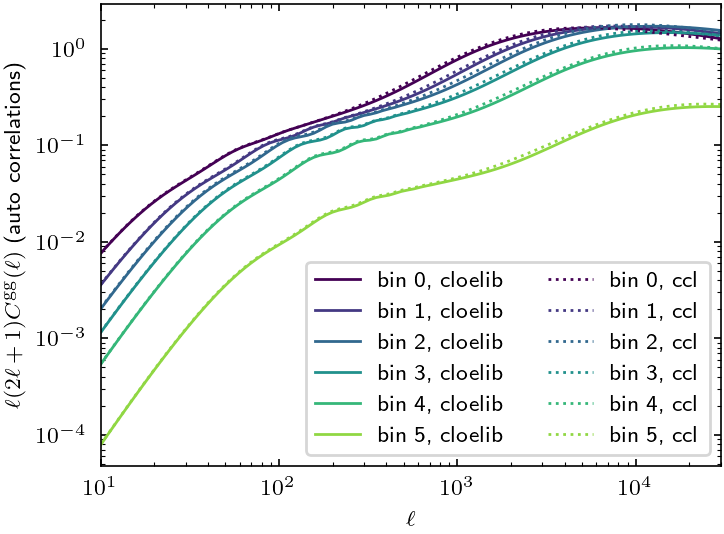

In [15]:
# plot


for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_pospos[:, i, i], label = f"bin {i}, cloelib", c=colors_pos[i])

for i, tomobin1 in enumerate(dndz_pos.keys()):
    plt.loglog(ells, ells*(2*ells+1)*twopoint_pospos_ccl[f'{tomobin1}-{tomobin1}'], label = f"bin {i}, ccl", c=colors_pos[i], ls=':')


plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$ (auto correlations)')
plt.legend(ncols=2)


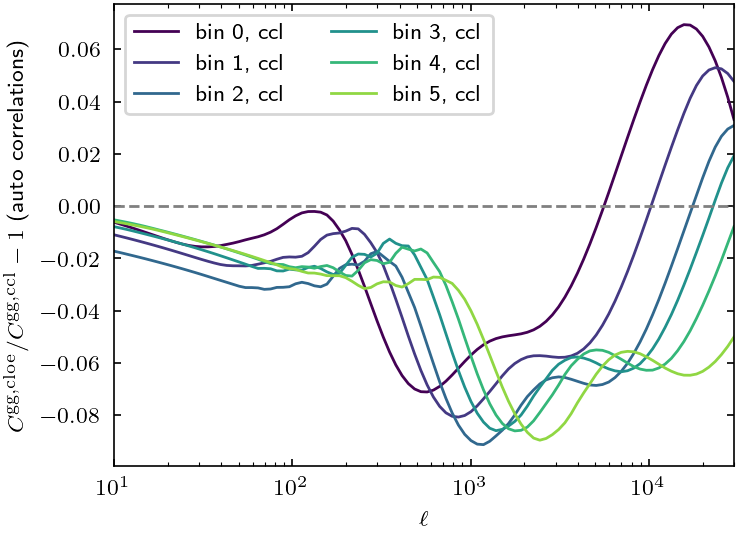

In [16]:
# plot relative differences


for i, tomobin1 in enumerate(dndz_pos.keys()):
    plt.semilogx(ells, cells_pospos[:, i, i]/twopoint_pospos_ccl[f'{tomobin1}-{tomobin1}']-1, label = f"bin {i}, ccl", c=colors_pos[i])


plt.xlabel(r'$\ell$')
plt.ylabel(r'$C^{\rm gg, cloe}/C^{\rm gg, ccl}-1$ (auto correlations)')
plt.legend(ncols=2)

plt.axhline(0, color='grey', ls='--')

### Shear-Position

In [17]:
# cloelib calculation

twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
cells_shepos = twopoint_shepos.get_Cl(ells, nl, nonlinear_perturbations.k)


In [18]:
# ccl calculation


twopoint_shepos_ccl={}

for tomobin1 in dndz_she.keys():
    for tomobin2 in dndz_pos.keys():
        if tomobin2>=tomobin1:
            twopoint_shepos_ccl[f'{tomobin1}-{tomobin2}']=ccl.angular_cl(cosmo_ccl, tracer_she_ccl[tomobin1], tracer_pos_ccl[tomobin2], ells)

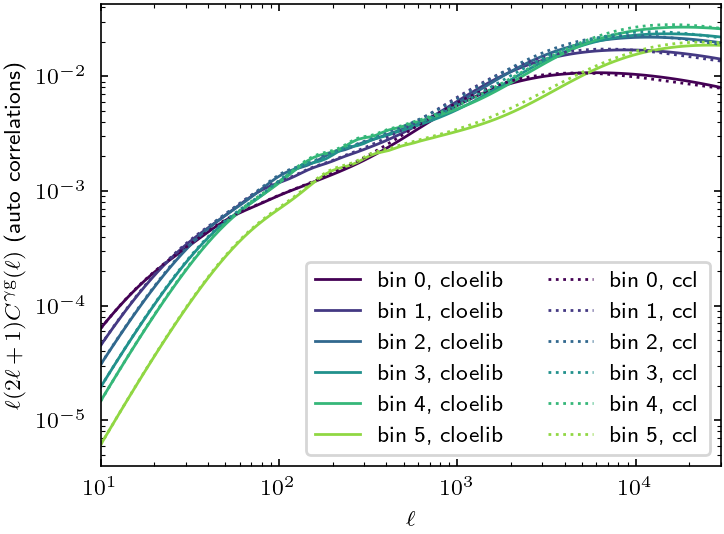

In [19]:
# plot


for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_shepos[:, i, i], label = f"bin {i}, cloelib", c=colors_pos[i])

for i, tomobin1 in enumerate(dndz_pos.keys()):
    plt.loglog(ells, ells*(2*ells+1)*twopoint_shepos_ccl[f'{tomobin1}-{tomobin1}'], label = f"bin {i}, ccl", c=colors_pos[i], ls=':')


plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm \gamma g}(\ell)$ (auto correlations)')
plt.legend(ncols=2)


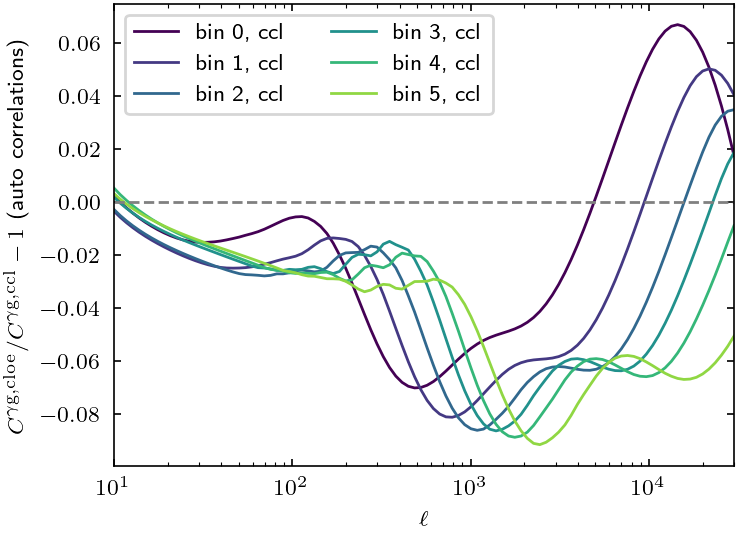

In [20]:
# plot relative differences


for i, tomobin1 in enumerate(dndz_pos.keys()):
    plt.semilogx(ells, cells_shepos[:, i, i]/twopoint_shepos_ccl[f'{tomobin1}-{tomobin1}']-1, label = f"bin {i}, ccl", c=colors_pos[i])


plt.xlabel(r'$\ell$')
plt.ylabel(r'$C^{\rm \gamma g, cloe}/C^{\rm \gamma g, ccl}-1$ (auto correlations)')
plt.legend(ncols=2)

plt.axhline(0, color='grey', ls='--')

### Shear-Shear

In [21]:
# cloelib calculation

twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
cells_sheshe = twopoint_sheshe.get_Cl(ells, nl, nonlinear_perturbations.k)


In [22]:
# ccl calculation


twopoint_sheshe_ccl={}

for tomobin1 in dndz_she.keys():
    for tomobin2 in dndz_she.keys():
        if tomobin2>=tomobin1:
            twopoint_sheshe_ccl[f'{tomobin1}-{tomobin2}']=ccl.angular_cl(cosmo_ccl, tracer_she_ccl[tomobin1], tracer_she_ccl[tomobin2], ells)

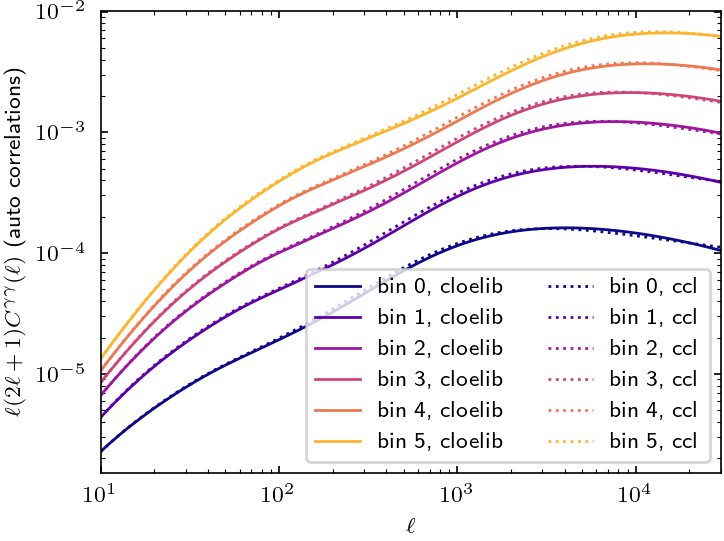

In [23]:
# plot


for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells_sheshe[:, i, i], label = f"bin {i}, cloelib", c=colors_she[i])

for i, tomobin1 in enumerate(dndz_she.keys()):
    plt.loglog(ells, ells*(2*ells+1)*twopoint_sheshe_ccl[f'{tomobin1}-{tomobin1}'], label = f"bin {i}, ccl", c=colors_she[i], ls=':')


plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm \gamma \gamma}(\ell)$ (auto correlations)')
plt.legend(ncols=2)


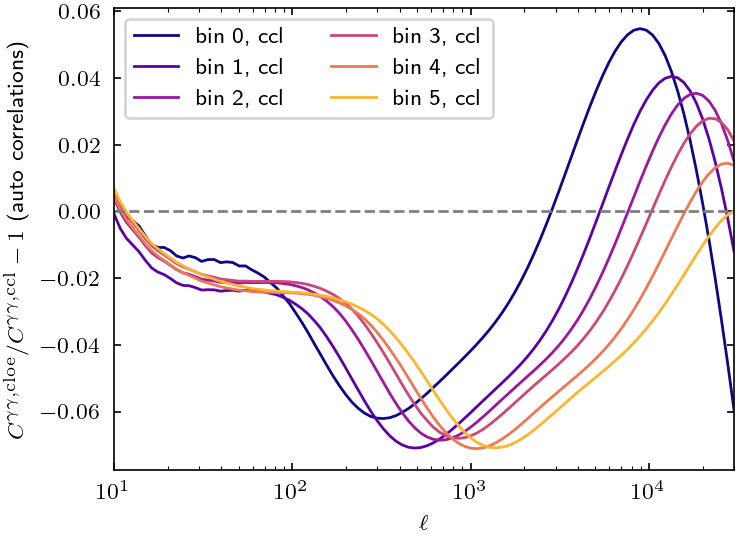

In [24]:
# plot relative differences


for i, tomobin1 in enumerate(dndz_she.keys()):
    plt.semilogx(ells, cells_sheshe[:, i, i]/twopoint_sheshe_ccl[f'{tomobin1}-{tomobin1}']-1, label = f"bin {i}, ccl", c=colors_she[i])


plt.xlabel(r'$\ell$')
plt.ylabel(r'$C^{\rm \gamma \gamma, cloe}/C^{\rm \gamma \gamma, ccl}-1$ (auto correlations)')
plt.legend(ncols=2)

plt.axhline(0, color='grey', ls='--')

## Calculate correlation functions

In [ ]:
# thetas

theta_deg = np.geomspace(5, 100, 10)/60 # Theta is in degrees

theta_rad = np.deg2rad(theta_deg)  # Angles in radians


# ells for integration
ells_integration = np.arange(2, 60000)  # Multipole moments
ks = nonlinear_perturbations.k  # Wavenumber grid


## Position - Position

In [26]:
# cloelib calcilation

correlation_function_GG = CorrelationFunction(twopoint_pospos)
xi_pospos = correlation_function_GG.get_xi(ells_integration, ks, theta_rad)


In [27]:
#ccl calculation

xi_pospos_ccl={}

for tomobins in twopoint_pospos_ccl.keys():
    xi_pospos_ccl[tomobins]=ccl.correlation(cosmo_ccl, ell=ells, C_ell=twopoint_pospos_ccl[tomobins], theta=theta_deg, type='NN', method='Bessel')


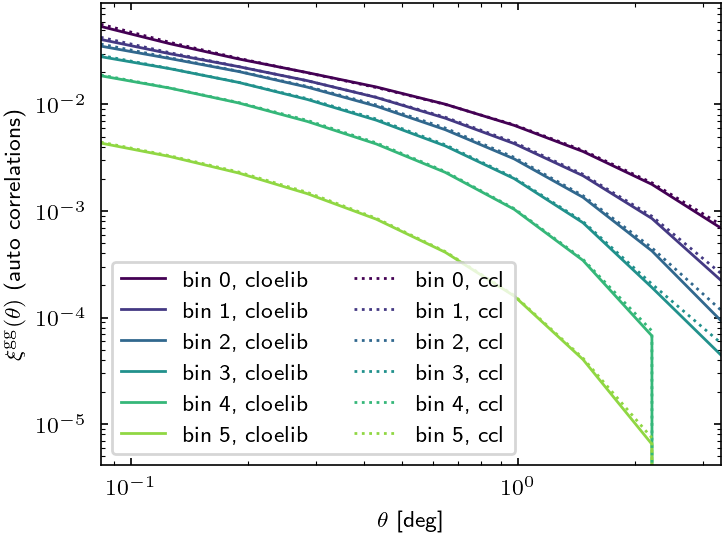

In [28]:
# plot


for i in range(0, 6):
    plt.loglog(theta_deg, xi_pospos[:, i, i], label = f"bin {i}, cloelib", c=colors_pos[i])

for i, tomobin1 in enumerate(dndz_pos.keys()):
    plt.loglog(theta_deg, xi_pospos_ccl[f'{tomobin1}-{tomobin1}'], label = f"bin {i}, ccl", c=colors_pos[i], ls=':')


plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\xi^{\rm gg}(\theta)$ (auto correlations)')
plt.legend(ncols=2)


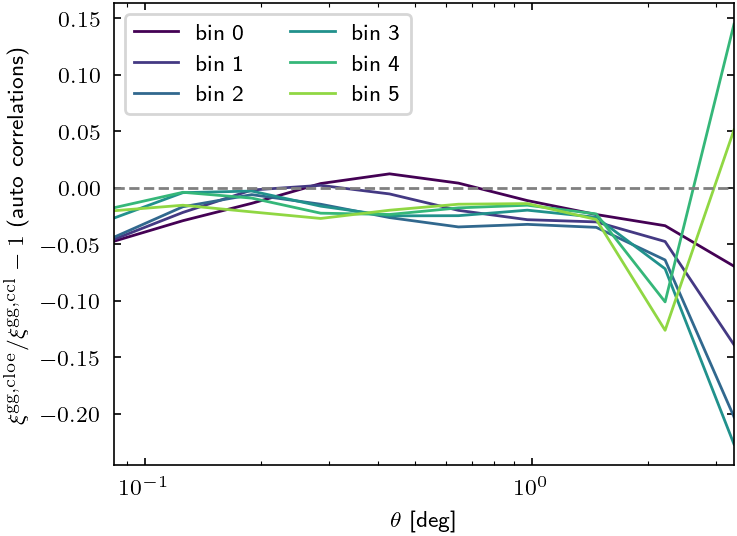

In [29]:
# plot relative differences


for i, tomobin1 in enumerate(dndz_pos.keys()):
    plt.semilogx(theta_deg, xi_pospos[:, i, i]/xi_pospos_ccl[f'{tomobin1}-{tomobin1}']-1, label = f"bin {i}", c=colors_pos[i])


plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\xi^{\rm gg, cloe}/\xi^{\rm gg, ccl}-1$ (auto correlations)')
plt.legend(ncols=2)

plt.axhline(0, color='grey', ls='--')

## Shear - Position

In [30]:
# cloelib calcilation

correlation_function_EG = CorrelationFunction(twopoint_shepos)
xi_shepos = correlation_function_EG.get_xi(ells_integration, ks, theta_rad)


In [31]:
#ccl calculation

xi_shepos_ccl={}

for tomobins in twopoint_shepos_ccl.keys():
    xi_shepos_ccl[tomobins]=ccl.correlation(cosmo_ccl, ell=ells, C_ell=twopoint_shepos_ccl[tomobins], theta=theta_deg, type='NG', method='Bessel')


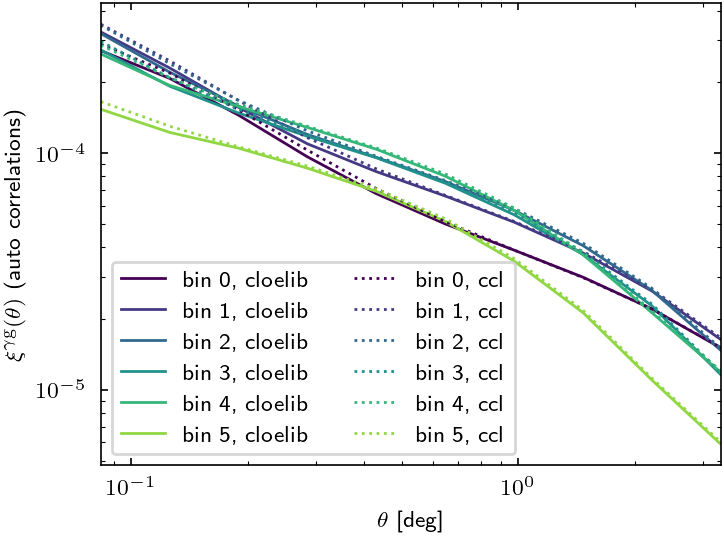

In [32]:
# plot


for i in range(0, 6):
    plt.loglog(theta_deg, xi_shepos[:, i, i], label = f"bin {i}, cloelib", c=colors_pos[i])

for i, tomobin1 in enumerate(dndz_pos.keys()):
    plt.loglog(theta_deg, xi_shepos_ccl[f'{tomobin1}-{tomobin1}'], label = f"bin {i}, ccl", c=colors_pos[i], ls=':')


plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\xi^{\rm \gamma g}(\theta)$ (auto correlations)')
plt.legend(ncols=2)


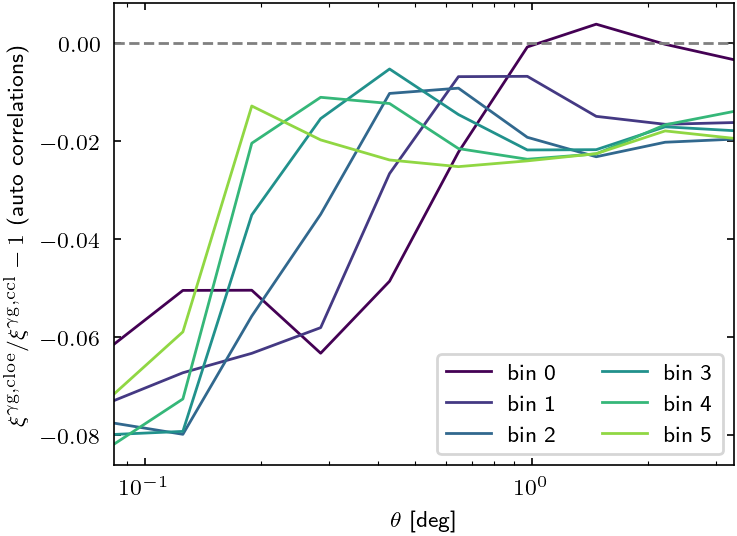

In [33]:
# plot relative differences


for i, tomobin1 in enumerate(dndz_pos.keys()):
    plt.semilogx(theta_deg, xi_shepos[:, i, i]/xi_shepos_ccl[f'{tomobin1}-{tomobin1}']-1, label = f"bin {i}", c=colors_pos[i])


plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\xi^{\rm \gamma g, cloe}/\xi^{\rm \gamma g, ccl}-1$ (auto correlations)')
plt.legend(ncols=2)

plt.axhline(0, color='grey', ls='--')

## Shear - Shear

In [34]:
# cloelib calcilation

correlation_function_EE = CorrelationFunction(twopoint_sheshe)
xi_sheshe_plus, xi_sheshe_minus = correlation_function_EE.get_xi(ells_integration, ks, theta_rad)


In [35]:
#ccl calculation

xi_sheshe_plus_ccl={}
xi_sheshe_minus_ccl={}


for tomobins in twopoint_shepos_ccl.keys():
    xi_sheshe_plus_ccl[tomobins]=ccl.correlation(cosmo_ccl, ell=ells, C_ell=twopoint_sheshe_ccl[tomobins], theta=theta_deg, type='GG+', method='Bessel')
    xi_sheshe_minus_ccl[tomobins]=ccl.correlation(cosmo_ccl, ell=ells, C_ell=twopoint_sheshe_ccl[tomobins], theta=theta_deg, type='GG-', method='Bessel')



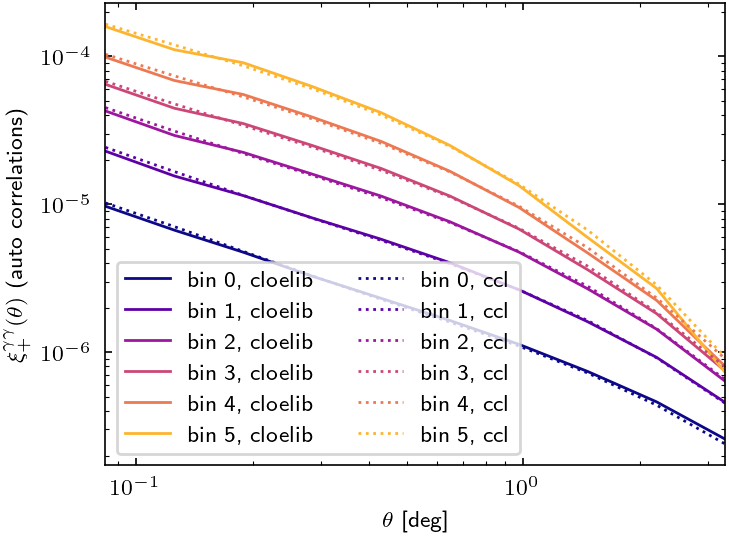

In [36]:
# plot


for i in range(0, 6):
    plt.loglog(theta_deg, xi_sheshe_plus[:, i, i], label = f"bin {i}, cloelib", c=colors_she[i])

for i, tomobin1 in enumerate(dndz_she.keys()):
    plt.loglog(theta_deg, xi_sheshe_plus_ccl[f'{tomobin1}-{tomobin1}'], label = f"bin {i}, ccl", c=colors_she[i], ls=':')


plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\xi^{\rm \gamma \gamma}_+(\theta)$ (auto correlations)')
plt.legend(ncols=2)


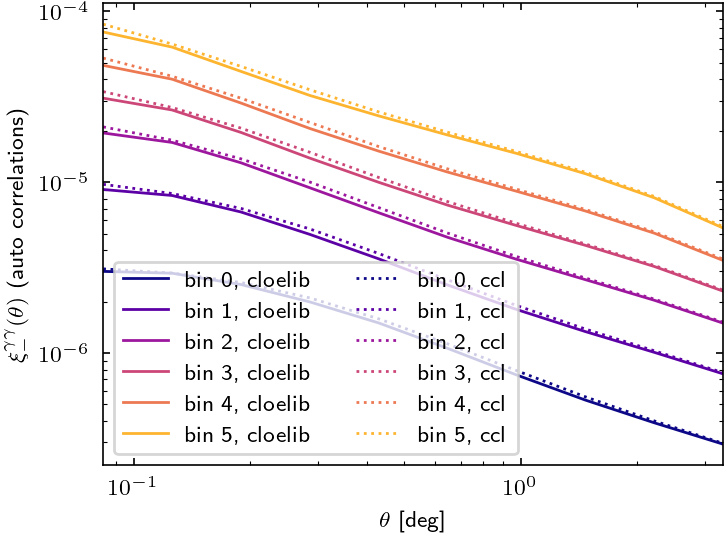

In [37]:
# plot


for i in range(0, 6):
    plt.loglog(theta_deg, xi_sheshe_minus[:, i, i], label = f"bin {i}, cloelib", c=colors_she[i])

for i, tomobin1 in enumerate(dndz_she.keys()):
    plt.loglog(theta_deg, xi_sheshe_minus_ccl[f'{tomobin1}-{tomobin1}'], label = f"bin {i}, ccl", c=colors_she[i], ls=':')


plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\xi^{\rm \gamma \gamma}_-(\theta)$ (auto correlations)')
plt.legend(ncols=2)


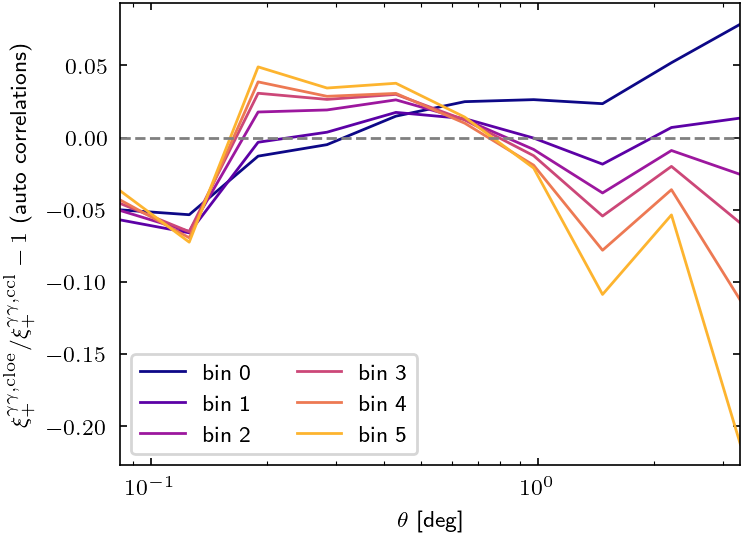

In [38]:
# plot relative differences


for i, tomobin1 in enumerate(dndz_she.keys()):
    plt.semilogx(theta_deg, xi_sheshe_plus[:, i, i]/xi_sheshe_plus_ccl[f'{tomobin1}-{tomobin1}']-1, label = f"bin {i}", c=colors_she[i])


plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\xi^{\rm \gamma \gamma, cloe}_+/\xi^{\rm \gamma \gamma, ccl}_+-1$ (auto correlations)')
plt.legend(ncols=2)

plt.axhline(0, color='grey', ls='--')

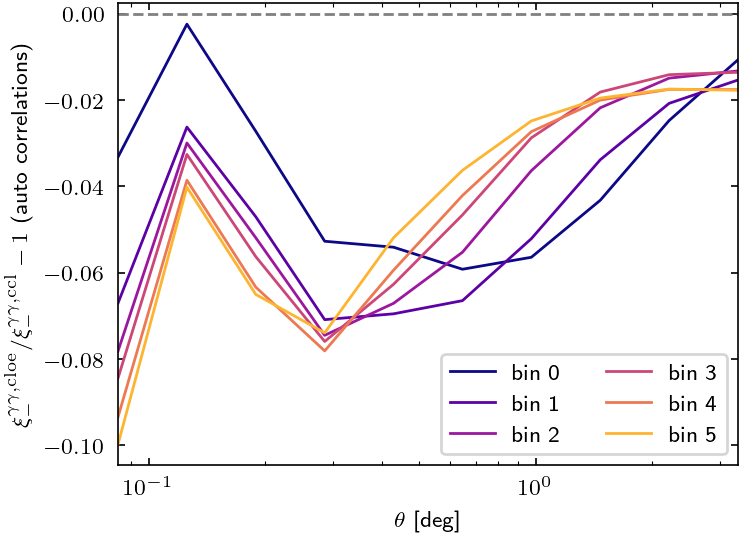

In [39]:
# plot relative differences


for i, tomobin1 in enumerate(dndz_she.keys()):
    plt.semilogx(theta_deg, xi_sheshe_minus[:, i, i]/xi_sheshe_minus_ccl[f'{tomobin1}-{tomobin1}']-1, label = f"bin {i}", c=colors_she[i])


plt.xlabel(r'$\theta$ [deg]')
plt.ylabel(r'$\xi^{\rm \gamma \gamma, cloe}_-/\xi^{\rm \gamma \gamma, ccl}_--1$ (auto correlations)')
plt.legend(ncols=2)

plt.axhline(0, color='grey', ls='--')